# Collins / transversity: azimuthal-acceptance comparison

The SoLID 3He (neutron) Collins fit across **five** pseudodata configurations,
all generated in this repo and all fitted at 500 replicas, against the world-data
fit as the reference.

| key | run directory | acceptance | binning | bins |
|---|---|---|---|---|
| `world` | `../data_world` | existing world data — **the reference** | — | 146 rows |
| `sbs` | `../data_world` | SBS projection — a second external reference, **stat-only panel** | — | 455 rows |
| `phifull` | `data_phifull` | full 2π (100%) | own | 1660 |
| `phi4seg_fullbin` | `data_phi4seg24deg_phifullbin` | 4 × 24° (26.7% nominal), both arms | **reused from `phifull`** | 1660 |
| `phi4seg` | `data_phi4seg24deg` | 4 × 24°, both arms | own | 169 |
| `phi4segFA_fullbin` | `data_phi4seg24degFA_phifullbin` | 4 × 24°, **forward angle only** (large-angle e⁻ keeps full 2π) | **reused from `phifull`** | 1660 |
| `phi4segFA` | `data_phi4seg24degFA` | 4 × 24°, forward angle only | own | 239 |

**`_fullbin` versus own bins is not a detail.** A `_fullbin` run inherits
`phifull`'s 1660 bins, so its errors are comparable bin by bin; an own-bins run
re-bins under its own acceptance, trading fewer bins for more events in each. The
own-bins runs therefore look *better* than their `_fullbin` twins at equal
acceptance — that is bin width, not physics.

**The nominal coverage is not the event cost.** The cut applies to the electron
and the hadron alike, so a coincidence survives roughly 26.7² ≈ 7.1%; measured,
the median surviving yield is 4.8%. See `README.md` in this directory.

*(Rewritten 2026-08-31: the previous version read `outputcollins*` directories
and `tmdlib.tmd` from the upstream tree, and covered 6×24° and 4×12°FA
configurations that do not exist here.)*

**SBS is a reference, not a SoLID configuration.** It is an external projection with no systematics model of its own, so there is a single SBS fit rather than a stat/syst pair, and it is drawn in the **stat-only panel only** — absent from every stat+syst panel and table rather than repeated there unchanged. Fitted at 500 replicas like everything else, so its 3.2% replica-sampling noise is the same as the rest.


In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

sys.path.insert(0, os.path.abspath('..'))   # tmd.py lives at the repo root
import tmd

# Its own gallery: pointed at 'gallery' this would overwrite the tracked
# phi-cut figures with a different comparison.
GALLERY = 'gallery_sbsenhanced3he'
os.makedirs(GALLERY, exist_ok=True)

Q2  = 2.4
tol = 7.04   # the band-scale calibration; see check.md -- it cancels in every
             # error RATIO below, so the comparisons are insensitive to it

LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/CJ15lo/CJ15lo_0000.dat
CJ15lo PDF set, member #0, version 2; LHAPDF ID = 12300
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/DSSFFlo/DSSFFlo_0211.dat
DSSFFlo PDF set, member #211, version 1; LHAPDF ID = 90211
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/DSSFFlo/DSSFFlo_0321.dat
DSSFFlo PDF set, member #321, version 1; LHAPDF ID = 90321
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/NNPDFpol11_100/NNPDFpol11_100_0000.dat
NNPDFpol11_100 PDF set, member #0, version 1; LHAPDF ID = 251000


## Load fit results

Each file is the raw per-replica parameter table (50 rows x `Nu,Nd,a,b,c,kt2,chi2`).

In [2]:
# SoLID 3He COMBINED WITH THE SBS PROJECTION (fit opt 'sbs+enhanced3he').
#
# Statistical only, and there is no stat+syst counterpart -- deliberately.
# The SBS projection carries no systematics model (prepare.py's prepare_sbs
# builds no fn, systabs or systrel), so 'sbs+enhanced3hesyst' does not exist:
# both fit scripts refuse it by name rather than let a stat-only SBS be
# combined with SoLID's stat+syst and silently over-weight SBS. Every
# stat+syst panel below is therefore switched off rather than left to render
# the world reference alone.
STAT = 'out-sbsenhanced3he_collins.dat'

# The 4x-counts twin, from the fit scripts' -c 4 flag. Only the SoLID half of the
# combined set is scaled: --counts never touches the SBS projection, because more
# SoLID beam time does not give SBS more events. So these curves are SBS at its own
# fixed luminosity plus SoLID at four times its nominal counts -- which is exactly
# the question, how much a phi-cut SoLID needs to make the pair competitive.
STAT_X4 = STAT.replace('.dat', '_x4counts.dat')

# REF is the denominator of every error ratio below.
REF = 'world'

# Three curves and the world reference, matching plot-transversity_phicompare.ipynb:
# the full-2pi run at nominal luminosity against the two phi-cut runs at 4x. There
# is no separate SBS-only curve here by design -- every curve in this notebook
# already contains SBS, so an SBS-alone entry would be a different quantity sharing
# an axis. The 1x twins of the two phi-cut runs live in the phicompare notebook's
# earlier revisions and in plot-transversity_phicompare_x4counts.ipynb.
RUNS = {
    'world':             {'dir': '../data_world',
                          # the world fit has no stat/syst variants -- the same
                          # fit is the reference in both panels
                          'files': {'': 'out-world_collins.dat'},
                          'label': r'$\rm world~data$',
                          'color': 'gray'},
    'phifull':           {'dir': 'data_phifull',
                          'files': {'': STAT},
                          'label': r'$\rm SBS+SoLID~2\pi$',
                          'color': 'black'},
    'phi4seg_fullbin_x4': {'dir': 'data_phi4seg24deg_phifullbin',
                          'files': {'': STAT_X4},
                          'label': r'$\rm SBS+4\times24^\circ~(2\pi~bins,~4\times~counts)$',
                          'color': 'green'},
    # same 4x24 deg acceptance as above; 169 bins of its own rather than phifull's
    # 1660, so it shares no bin with the others -- compare the shape, never a value
    # at a given bin index.
    'phi4seg_x4':        {'dir': 'data_phi4seg24deg',
                          'files': {'': STAT_X4},
                          'label': r'$\rm SBS+4\times24^\circ~(own~bins,~4\times~counts)$',
                          'color': 'darkorange'},
}
# Every loop below iterates runs_for(suffix), so each run appears in exactly the
# panels it has a fit for. With VARIANTS = [''] that is the stat panel only.
def runs_for(suffix):
    return [(run, cfg) for run, cfg in RUNS.items() if suffix in cfg['files']]

VARIANTS = ['']   # no stat+syst variant exists for this opt

par = {}
for run, cfg in RUNS.items():
    for suf in VARIANTS:
        if suf not in cfg['files']:
            print(f'{run+suf:24s} {"-- no fit; absent from this panel":52s}')
            continue
        path = os.path.join(cfg['dir'], cfg['files'][suf])
        par[run + suf] = pd.read_csv(path, sep=r'\s+', index_col=False)
        print(f'{run+suf:24s} {path:60s} {len(par[run+suf])} replicas')


world                    ../data_world/out-world_collins.dat                          500 replicas
phifull                  data_phifull/out-sbsenhanced3he_collins.dat                  500 replicas
phi4seg_fullbin_x4       data_phi4seg24deg_phifullbin/out-sbsenhanced3he_collins_x4counts.dat 500 replicas
phi4seg_x4               data_phi4seg24deg/out-sbsenhanced3he_collins_x4counts.dat    500 replicas


### Fitted parameters, run by run

Mean ± std across replicas — a first look before propagating into $h_1$.

In [3]:
rows = []
for key, p in par.items():
    r = {'run': key}
    for c in p.columns:
        r[c] = f'{p[c].mean():.4f} +- {p[c].std():.4f}'
    rows.append(r)
partable = pd.DataFrame(rows).set_index('run')
partable

,Nu,Nd,a,b,c,kt2,Nu_err,Nd_err,a_err,b_err,c_err,kt2_err,chi2,ndof,edm
run,,,,,,,,,,,,,,,
world,0.4007 +- 0.0125,-0.4511 +- 0.0311,1.0008 +- 0.0537,3.0103 +- 0.3782,0.0000 +- 0.0000,0.2496 +- 0.0224,0.0123 +- 0.0010,0.0313 +- 0.0014,0.0558 +- 0.0010,0.3842 +- 0.0075,nan +- nan,0.0207 +- 0.0006,140.5382 +- 16.0417,141.0000 +- 0.0000,0.0000 +- 0.0000
phifull,0.4063 +- 0.0618,-0.4570 +- 0.0693,1.0019 +- 0.0251,2.9967 +- 0.0358,0.0054 +- 0.2034,0.2500 +- 0.0011,0.0085 +- 0.0112,0.0094 +- 0.0126,0.0081 +- 0.0034,0.0290 +- 0.0021,0.0338 +- 0.0557,0.0010 +- 0.0000,2106.3210 +- 64.2837,2255.0000 +- 0.0000,0.0027 +- 0.0233
phi4seg_fullbin_x4,0.4176 +- 0.1278,-0.4695 +- 0.1426,1.0040 +- 0.0448,2.9877 +- 0.0808,0.0469 +- 0.3964,0.2501 +- 0.0022,0.0266 +- 0.0285,0.0296 +- 0.0321,0.0184 +- 0.0084,0.0594 +- 0.0067,0.1207 +- 0.1762,0.0021 +- 0.0000,2106.6600 +- 64.3631,2255.0000 +- 0.0000,0.0017 +- 0.0062
phi4seg_x4,0.4119 +- 0.0904,-0.4633 +- 0.1013,1.0040 +- 0.0318,2.9944 +- 0.0713,0.0128 +- 0.2813,0.2500 +- 0.0022,0.0166 +- 0.0204,0.0183 +- 0.0230,0.0156 +- 0.0058,0.0565 +- 0.0045,0.0692 +- 0.1179,0.0022 +- 0.0000,619.1954 +- 36.6806,764.0000 +- 0.0000,0.0021 +- 0.0183


## Calculate $xh_1(x)$

Identical to `h1calc()` in `plot-transversity_phifull.ipynb`: for each $x$, evaluate
`tmd.h1col` once per replica using that replica's own parameters, then take
central value = mean, error = `tol` × std.

In [4]:
def h1calc(pset, Q2, tol):
    rows = []
    X = np.linspace(1e-3, 1, 200)
    pset = pset.reset_index(drop=True)
    for x in X:
        xu, xd, ratio = [], [], []
        for i in range(len(pset)):
            h1 = tmd.h1col(x, Q2, 'proton', pset.loc[i])
            xu.append(x * h1[2])
            xd.append(x * h1[1])
            ratio.append(h1[1] / h1[2])
        rows.append({'x': x,
                     'xu': np.mean(xu),  'Exu': tol * np.std(xu),
                     'xd': np.mean(xd),  'Exd': tol * np.std(xd),
                     'd/u': np.mean(ratio), 'Ed/u': tol * np.std(ratio)})
    return pd.DataFrame(rows)

In [5]:
%%time
h1 = {}
for key in par:
    h1[key] = h1calc(par[key], Q2, tol)
    print('done', key)

/tmp/ipykernel_3484261/1797581884.py:11: RuntimeWarning: invalid value encountered in double_scalars
  ratio.append(h1[1] / h1[2])


done world


done phifull


done phi4seg_fullbin_x4


done phi4seg_x4
CPU times: user 33.1 s, sys: 9.99 ms, total: 33.1 s
Wall time: 33.3 s


## $xh_1(x)$ bands, three runs overlaid

Top panel: $u$ (solid) and $d$ (dashed) transversity bands. Bottom panel: the
uncertainty of each φ-cut run relative to the full-2π baseline — values above 1
mean the φ cut degrades the projection.

In [6]:
def band_plot(suffix, fname, title):
    fig = plt.figure(figsize=(6.5, 10))

    ax = fig.add_subplot(2, 1, 1)
    for run, cfg in runs_for(suffix):
        d = h1[run + suffix]
        ax.fill_between(d['x'], d['xu'] - d['Exu'], d['xu'] + d['Exu'],
                        color=cfg['color'], alpha=0.30, linewidth=0)
        ax.fill_between(d['x'], d['xd'] - d['Exd'], d['xd'] + d['Exd'],
                        color=cfg['color'], alpha=0.30, linewidth=0)
        ax.plot(d['x'], d['xu'], color=cfg['color'], linewidth=1.2, label=cfg['label'])
        ax.plot(d['x'], d['xd'], color=cfg['color'], linewidth=1.2, linestyle='--')
    ax.axhline(y=0, linestyle='-', color='black', alpha=0.9, linewidth=1)
    ax.axvline(x=0.05, linestyle='--', color='black', alpha=0.7, linewidth=1)
    ax.axvline(x=0.60, linestyle='--', color='black', alpha=0.7, linewidth=1)
    ax.set_ylabel(r'$xh_1(x)$', size=25)
    ax.set_xlim(0, 0.7)
    ax.set_ylim(-0.45, 0.45)
    ax.set_xticklabels([])
    ax.tick_params(axis='both', which='both', direction='in', labelsize=20)
    ax.text(0.5, 0.96, title, horizontalalignment='center', verticalalignment='center',
            transform=ax.transAxes, fontsize=17)
    ax.text(0.03, 0.10, r'$u\rm~solid,~d~dashed$', transform=ax.transAxes, fontsize=15)
    ax.legend(loc='lower right', frameon=False, fontsize=13)

    ax = fig.add_subplot(2, 1, 2)
    ref = h1[REF + suffix]
    for run, cfg in runs_for(suffix):
        if run == REF:
            continue
        d = h1[run + suffix]
        ax.plot(d['x'], ref['Exu'] / d['Exu'], color=cfg['color'], alpha=0.8,
                linestyle='-',  linewidth=3, label=cfg['label'] + r'$~u$')
        ax.plot(d['x'], ref['Exd'] / d['Exd'], color=cfg['color'], alpha=0.8,
                linestyle='--', linewidth=3, label=cfg['label'] + r'$~d$')
    ax.axhline(y=1, linestyle='-', color='black', alpha=0.6, linewidth=1)
    for y in (5, 10, 15, 20):
        ax.axhline(y=y, linestyle=':', color='black', alpha=0.5, linewidth=1)
    ax.axvline(x=0.05, linestyle='--', color='black', alpha=0.7, linewidth=1)
    ax.axvline(x=0.60, linestyle='--', color='black', alpha=0.7, linewidth=1)
    ax.set_xlabel(r'$x$', size=25)
    ax.set_ylabel(r'$\rm Error^{world}/Error$', size=20)
    ax.set_xlim(0, 0.7)
    ax.set_ylim(0, 40)
    ax.tick_params(axis='both', which='both', direction='in', labelsize=20)
    ax.legend(loc='upper right', frameon=False, fontsize=9, ncol=2)

    fig.tight_layout()
    fig.savefig(f'{GALLERY}/{fname}')
    return fig

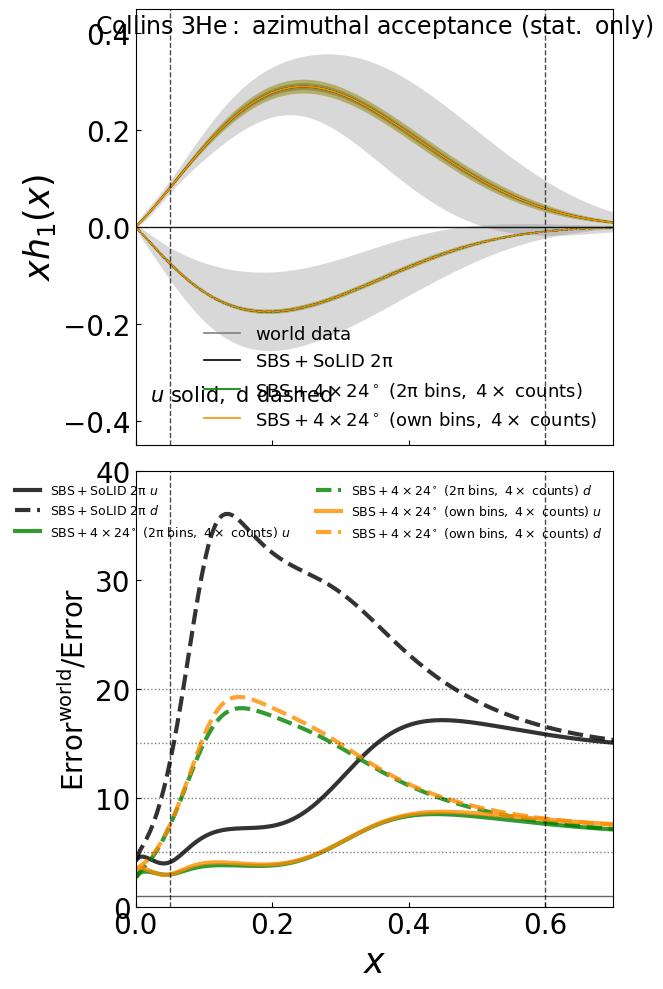

In [7]:
band_plot('', 'trans-phicompare.pdf',
          r'$\rm Collins~3He:~azimuthal~acceptance~(stat.~only)$');

In [8]:
# stat+syst band figure omitted: 'sbs+enhanced3he' has no syst
# variant, so this panel would show the world reference alone.


## Uncertainty ratio at representative $x$

Same information as the bottom panel above, tabulated at the $x$ values that
bracket the SoLID coverage (0.05–0.60).

In [9]:
XPTS = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

rows = []
for suffix, sname in [('', 'stat')]:
    ref = h1[REF + suffix]
    for run, cfg in runs_for(suffix):
        if run == REF:
            continue
        d = h1[run + suffix]
        for q, lab in [('Exu', 'u'), ('Exd', 'd')]:
            r = {'variant': sname, 'run': run, 'quark': lab}
            for x in XPTS:
                j = int(np.argmin(np.abs(d['x'].values - x)))
                r[f'x={x}'] = round(ref[q].values[j] / d[q].values[j], 2)
            rows.append(r)
ratios = pd.DataFrame(rows).set_index(['variant', 'run', 'quark'])
print('Error^world / Error  (larger = SoLID better; 20 means 20x more precise)')
ratios

Error^world / Error  (larger = SoLID better; 20 means 20x more precise)


x=0.05  x=0.1  x=0.2  x=0.3  x=0.4  x=0.5  \
variant run                quark                                              
stat    phifull            u        4.09   6.45   7.42  11.81  16.59  16.86   
                           d       13.53  31.77  32.40  28.74  23.28  18.91   
        phi4seg_fullbin_x4 u        2.95   3.71   3.78   5.93   8.29   8.28   
                           d        7.58  15.19  17.45  14.52  11.20   9.00   
        phi4seg_x4         u        2.96   3.99   3.89   5.96   8.41   8.57   
                           d        7.62  15.85  18.20  14.84  11.32   9.18   

                                  x=0.6  
variant run                quark         
stat    phifull            u      15.83  
                           d      16.54  
        phi4seg_fullbin_x4 u       7.61  
                           d       7.80  
        phi4seg_x4         u       8.01  
                           d       8.09

## $-h_1^d/h_1^u$

/tmp/ipykernel_3484261/770007612.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower right', frameon=False, fontsize=13)


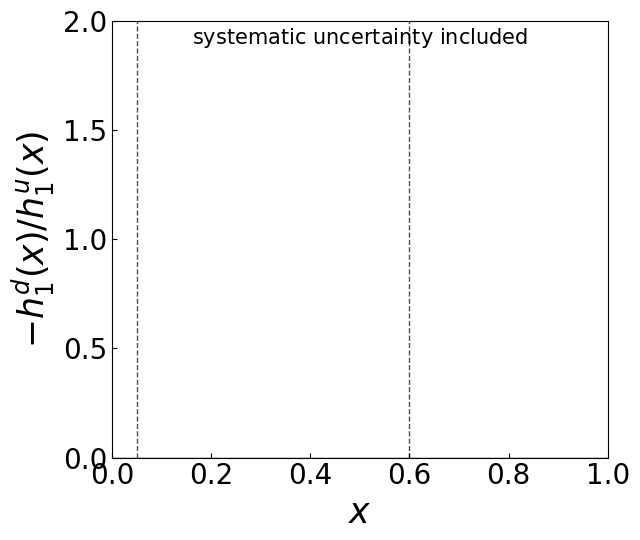

In [10]:
fig = plt.figure(figsize=(6.5, 5.5))
ax = fig.add_subplot(1, 1, 1)
for run, cfg in runs_for('syst'):          # SBS has no syst fit; it drops out here
    d = h1[run + 'syst']
    ax.fill_between(d['x'], -d['d/u'] - d['Ed/u'], -d['d/u'] + d['Ed/u'],
                    color=cfg['color'], alpha=0.30, linewidth=0)
    ax.plot(d['x'], -d['d/u'], color=cfg['color'], linewidth=1.2, label=cfg['label'])
ax.axhline(y=0, linestyle='-', color='black', alpha=0.9, linewidth=1)
ax.axvline(x=0.05, linestyle='--', color='black', alpha=0.7, linewidth=1)
ax.axvline(x=0.60, linestyle='--', color='black', alpha=0.7, linewidth=1)
ax.set_xlabel(r'$x$', size=25)
ax.set_ylabel(r'$-h_1^d(x)/h_1^u(x)$', size=25)
ax.set_xlim(0, 1)
ax.set_ylim(0, 2)
ax.tick_params(axis='both', which='both', direction='in', labelsize=20)
ax.text(0.5, 0.96, r'$\rm systematic~uncertainty~included$',
        horizontalalignment='center', verticalalignment='center',
        transform=ax.transAxes, fontsize=15)
ax.legend(loc='lower right', frameon=False, fontsize=13)
fig.tight_layout()
fig.savefig(f'{GALLERY}/trans-doveru-phicompare.pdf')

## Tensor charge $g_T$

`gtcalc` integrates over all $x$; `gttruncate` restricts to the measured range
$0.05 < x < 0.6$ — the truncated one is the honest comparison, since the full
integral extrapolates outside SoLID coverage.

`tmd.gt_fast` replaces `tmd.gt` here: fixed-node quadrature on a grid shared by
all replicas, ~780x faster and agreeing with `gt` to 4e-9 (truncated) and 4e-7
(full). `gt` remains the reference for one-off authoritative numbers.


In [11]:
def gtcalc(pset, Q2, tol, xl=None, xu=None):
    pset = pset.reset_index(drop=True)
    gu, gd, gt = [], [], []
    for i in range(len(pset)):
        tmp = tmd.gt_fast(Q2, pset.loc[i]) if xl is None else tmd.gt_fast(Q2, pset.loc[i], xl, xu)
        gu.append(tmp['u']); gd.append(tmp['d']); gt.append(tmp['u-d'])
    return {'u': np.mean(gu), 'Eu': np.std(gu) * tol,
            'd': np.mean(gd), 'Ed': np.std(gd) * tol,
            'u-d': np.mean(gt), 'Eu-d': np.std(gt) * tol}

gt  = {k: gtcalc(par[k], Q2, tol) for k in par}
gtt = {k: gtcalc(par[k], Q2, tol, 0.05, 0.6) for k in par}

In [12]:
rows = []
for k in par:
    rows.append({'run': k,
                 'gT(u)':  f"{gt[k]['u']:.4f} +- {gt[k]['Eu']:.4f}",
                 'gT(d)':  f"{gt[k]['d']:.4f} +- {gt[k]['Ed']:.4f}",
                 'gT(u-d)': f"{gt[k]['u-d']:.4f} +- {gt[k]['Eu-d']:.4f}",
                 'gT trunc (u-d)': f"{gtt[k]['u-d']:.4f} +- {gtt[k]['Eu-d']:.4f}"})
pd.DataFrame(rows).set_index('run')

,gT(u),gT(d),gT(u-d),gT trunc (u-d)
run,,,,
world,0.5475 +- 0.1175,-0.3766 +- 0.1715,0.9241 +- 0.2111,0.7654 +- 0.1701
phifull,0.5469 +- 0.0155,-0.3760 +- 0.0096,0.9229 +- 0.0201,0.7650 +- 0.0107
phi4seg_fullbin_x4,0.5468 +- 0.0240,-0.3758 +- 0.0175,0.9225 +- 0.0286,0.7650 +- 0.0192
phi4seg_x4,0.5469 +- 0.0237,-0.3758 +- 0.0164,0.9226 +- 0.0302,0.7651 +- 0.0209


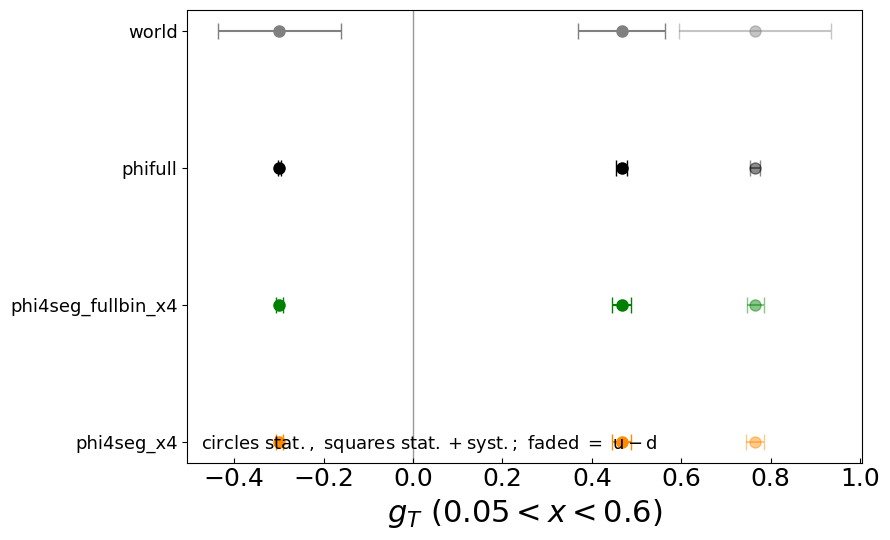

In [13]:
fig = plt.figure(figsize=(9, 5.5))
ax = fig.add_subplot(1, 1, 1)

ypos = {}
y = 0
for run, cfg in RUNS.items():
    for suffix, sname in [('', 'stat')]:
        if suffix not in cfg['files']:
            continue          # SBS is stat-only -- one row, in the stat block
        if run == REF and suffix == 'syst':
            continue          # world points both variants at the same fit
        key = run + suffix
        ypos[key] = y
        src = gtt[key]
        ls = 'o' if suffix == '' else 's'
        ax.errorbar(src['u'],   y, xerr=src['Eu'],   marker=ls, color=cfg['color'],
                    markersize=8, capsize=6)
        ax.errorbar(src['d'],   y, xerr=src['Ed'],   marker=ls, color=cfg['color'],
                    markersize=8, capsize=6)
        ax.errorbar(src['u-d'], y, xerr=src['Eu-d'], marker=ls, color=cfg['color'],
                    markersize=8, capsize=6, alpha=0.45)
        y -= 1

ax.set_yticks(list(ypos.values()))
ax.set_yticklabels(list(ypos.keys()), fontsize=13)
ax.set_xlabel(r'$g_T~(0.05<x<0.6)$', size=22)
ax.tick_params(axis='x', which='both', direction='in', labelsize=18)
ax.axvline(x=0, linestyle='-', color='black', alpha=0.4, linewidth=1)
ax.text(0.02, 0.03, r'$\rm circles~stat.,~squares~stat.+syst.;~faded~=~u-d$',
        transform=ax.transAxes, fontsize=13)
fig.tight_layout()
fig.savefig(f'{GALLERY}/gt-phicompare.pdf')

## Summary

Relative $g_T^{u-d}$ (truncated) uncertainty, normalised to **world** — the
single-number version of the whole comparison, and the one to quote for
"how much does SoLID improve on current knowledge".

In [14]:
for suffix, sname in [('', 'stat')]:
    ref = gtt[REF + suffix]['Eu-d']
    print(f'--- {sname} ---')
    for run, cfg in runs_for(suffix):
        r = ref / gtt[run + suffix]['Eu-d']
        print(f"  {run:18s} E(gT u-d) = {gtt[run+suffix]['Eu-d']:.4f}"
              f"   world/this = {r:6.2f}x")

--- stat ---
  world              E(gT u-d) = 0.1701   world/this =   1.00x
  phifull            E(gT u-d) = 0.0107   world/this =  15.86x
  phi4seg_fullbin_x4 E(gT u-d) = 0.0192   world/this =   8.88x
  phi4seg_x4         E(gT u-d) = 0.0209   world/this =   8.14x
